# **Forecasting Exchange Rates using Time Series Analysis**

Importing Required Libraries

In [26]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt

# Time series libraries
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

Explanation:

In this step, we import all required Python libraries.
pandas is used for data handling, matplotlib is used for plotting graphs, statsmodels is used for time series models, and sklearn is used for calculating error metrics.

# **Loading the Dataset**

In [27]:
df = pd.read_csv('/content/drive/MyDrive/ASSIGNMENTS/Time Series/exchange_rate.csv')

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Display column names
print("Columns in the dataset:")
print(df.columns)

# Display first five rows
df.head()

Columns in the dataset:
Index(['date', 'Ex_rate'], dtype='object')


,date,Ex_rate
0,01-01-1990 00:00,0.7855
1,02-01-1990 00:00,0.7818
2,03-01-1990 00:00,0.7867
3,04-01-1990 00:00,0.7860
4,05-01-1990 00:00,0.7849


Explanation

Here, the dataset is loaded using read_csv().
The column names are also cleaned using strip() so that extra spaces do not create errors.

# **Rename Columns Properly**

In [28]:
# Rename first column as date and second column as Ex_rate
df = df.rename(columns={
    df.columns[0]: 'date',
    df.columns[1]: 'Ex_rate'
})

# Check column names again
print(df.columns)

# Display first five rows
df.head()

Index(['date', 'Ex_rate'], dtype='object')


,date,Ex_rate
0,01-01-1990 00:00,0.7855
1,02-01-1990 00:00,0.7818
2,03-01-1990 00:00,0.7867
3,04-01-1990 00:00,0.7860
4,05-01-1990 00:00,0.7849


# **Convert Date Column and Set It as Index**

In [29]:
# Convert date column into datetime format
df['date'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')

# Set date column as index
df.set_index('date', inplace=True)

# Sort the data by date
df = df.sort_index()

# Display first five rows
df.head()

,Ex_rate
date,
1990-01-01,0.7855
1990-01-02,0.7818
1990-01-03,0.7867
1990-01-04,0.7860
1990-01-05,0.7849


Explanation

Since this is a time series dataset, the date column must be converted into datetime format.
After conversion, the date column is set as the index. This makes the dataset suitable for time series analysis.

# **Check Basic Information of Dataset**

In [30]:
print("Shape of dataset:", df.shape)

print("\nDataset information:")
df.info()

print("\nSummary statistics:")
df.describe()

Shape of dataset: (7588, 1)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7588 entries, 1990-01-01 to 2010-10-10
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ex_rate  7588 non-null   float64
dtypes: float64(1)
memory usage: 118.6 KB

Summary statistics:


,Ex_rate
count,7588.000000
mean,0.776974
std,0.136620
min,0.483297
25%,0.701422
50%,0.761377
75%,0.873477
max,1.102536


Explanation

This step is used to understand the basic structure of the dataset.
We check the number of rows and columns, data types, and statistical values such as mean, minimum, maximum, and standard deviation.

# **Check Missing Values**

In [31]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Ex_rate    0
dtype: int64


Explanation

Missing values can affect the performance of the forecasting models.
So, we check whether the dataset contains any missing values.

# **Handle Missing Values**

In [32]:
# Convert exchange rate column to numeric
df['Ex_rate'] = pd.to_numeric(df['Ex_rate'], errors='coerce')

# Fill missing values using forward fill
df['Ex_rate'] = df['Ex_rate'].fillna(method='ffill')

# Fill remaining missing values using backward fill
df['Ex_rate'] = df['Ex_rate'].fillna(method='bfill')

# Check missing values again
print(df.isnull().sum())

Ex_rate    0
dtype: int64


Explanation

The exchange rate column is converted into numeric format.
If any missing values are found, they are filled using forward fill and backward fill methods.

Forward fill uses the previous value to fill missing data.
Backward fill uses the next value to fill missing data.

# **Plot the Original Time Series**

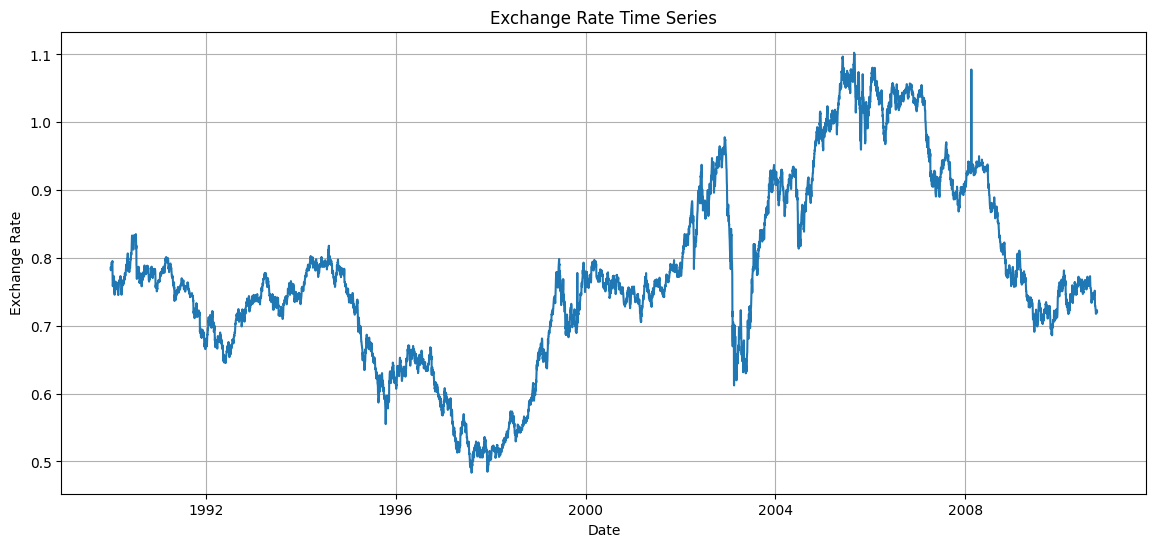

In [33]:
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Ex_rate'])
plt.title('Exchange Rate Time Series')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.grid(True)
plt.show()

Explanation

This graph shows the movement of exchange rates over time.
It helps us observe the trend, fluctuations, and possible anomalies in the dataset.

# **Check Stationarity using ADF Test**

In [34]:
result = adfuller(df['Ex_rate'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] <= 0.05:
    print("Result: The data is stationary")
else:
    print("Result: The data is not stationary")

ADF Statistic: -1.6649941807382342
p-value: 0.4492327353597477
Result: The data is not stationary


Explanation

The Augmented Dickey-Fuller test is used to check whether the time series is stationary or not.

# **Apply Differencing**

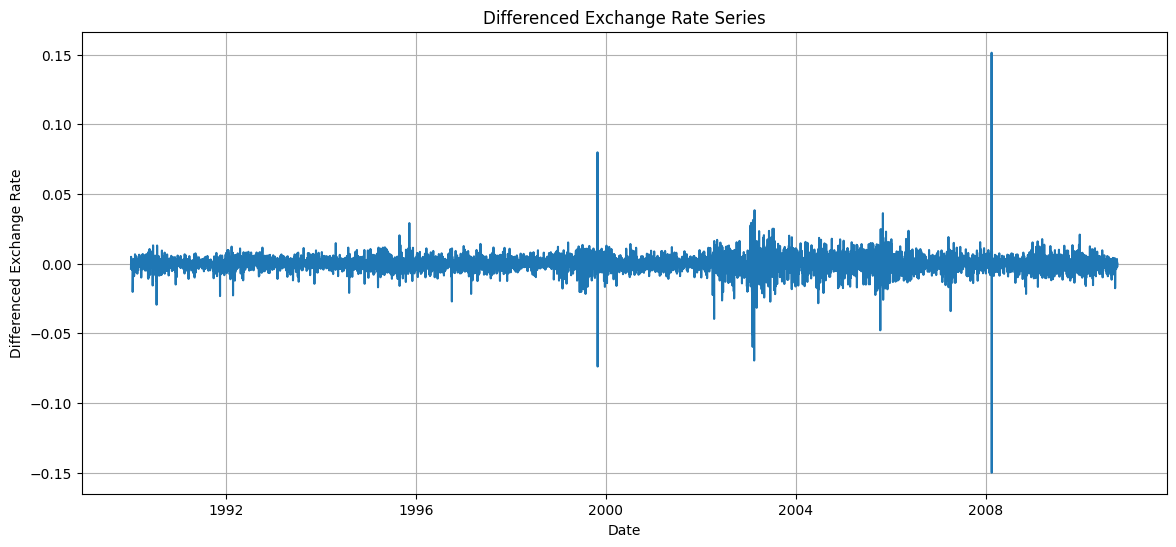

In [35]:
df['Ex_rate_diff'] = df['Ex_rate'].diff()

# Remove missing value created after differencing
df_diff = df['Ex_rate_diff'].dropna()

plt.figure(figsize=(14, 6))
plt.plot(df_diff)
plt.title('Differenced Exchange Rate Series')
plt.xlabel('Date')
plt.ylabel('Differenced Exchange Rate')
plt.grid(True)
plt.show()

Explanation

If the time series is not stationary, differencing is applied.
Differencing means subtracting the previous value from the current value.

# **ACF and PACF Plots**

<Figure size 1200x500 with 0 Axes>

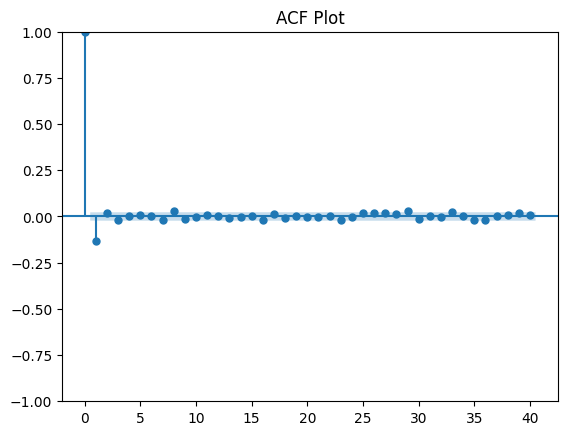

<Figure size 1200x500 with 0 Axes>

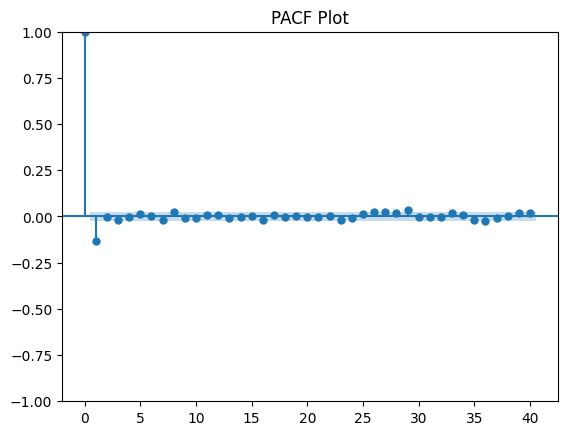

In [36]:
plt.figure(figsize=(12, 5))
plot_acf(df_diff, lags=40)
plt.title('ACF Plot')
plt.show()

plt.figure(figsize=(12, 5))
plot_pacf(df_diff, lags=40)
plt.title('PACF Plot')
plt.show()

Explanation

ACF and PACF plots are used to select ARIMA parameters.

ARIMA has three parameters:

p = Auto Regressive order
d = Differencing order
q = Moving Average order

Since first-order differencing is applied, we use d = 1.

# **Train-Test Split**

In [37]:
# Use only exchange rate column
data = df['Ex_rate']

# Split data into 80% training and 20% testing
train_size = int(len(data) * 0.8)

train = data.iloc[:train_size]
test = data.iloc[train_size:]

print("Total records:", len(data))
print("Training records:", len(train))
print("Testing records:", len(test))

Total records: 7588
Training records: 6070
Testing records: 1518


Explanation

The dataset is divided into training and testing parts.

Training data is used to build the model.
Testing data is used to evaluate the model performance.

Here, 80% of the data is used for training and 20% is used for testing.

# **ARIMA Model**

**Build ARIMA Model**

In [38]:
arima_model = ARIMA(train, order=(1, 1, 1))

arima_result = arima_model.fit()

print(arima_result.summary())

                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 6070
Model:                 ARIMA(1, 1, 1)   Log Likelihood               22719.046
Date:                Sun, 07 Jun 2026   AIC                         -45432.092
Time:                        13:04:52   BIC                         -45411.959
Sample:                    01-01-1990   HQIC                        -45425.104
                         - 08-14-2006                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5972      0.062     -9.648      0.000      -0.719      -0.476
ma.L1          0.5398      0.064      8.430      0.000       0.414       0.665
sigma2      3.281e-05   1.95e-07    168.198      0.0

Explanation

In this step, the ARIMA model is created using order (1,1,1).

This means:

p = 1
d = 1
q = 1

This is a simple and commonly used ARIMA model for forecasting.

# **ARIMA Residual Analysis**

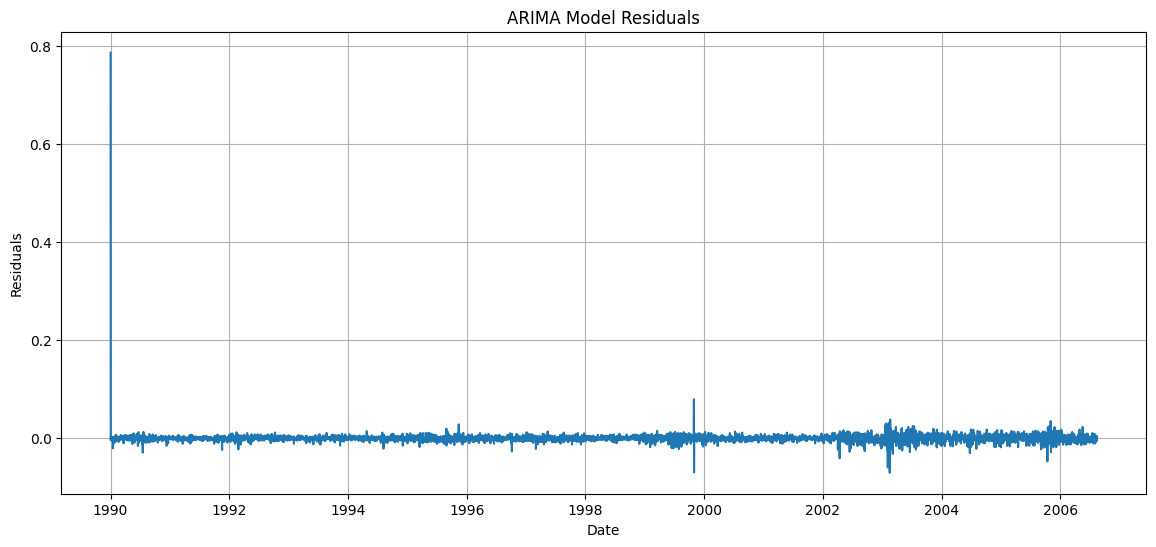

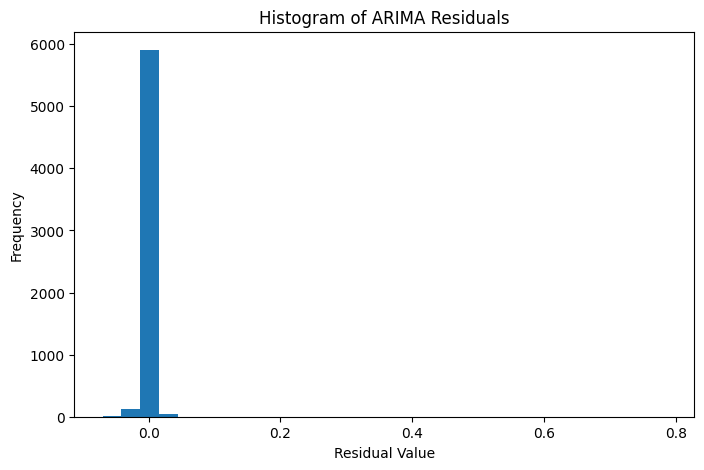

In [39]:
residuals = arima_result.resid

plt.figure(figsize=(14, 6))
plt.plot(residuals)
plt.title('ARIMA Model Residuals')
plt.xlabel('Date')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=30)
plt.title('Histogram of ARIMA Residuals')
plt.xlabel('Residual Value')
plt.ylabel('Frequency')
plt.show()

Explanation

Residuals are the difference between actual and predicted values.

Residual = Actual value - Predicted value

If the residuals do not show any clear pattern, the model can be considered acceptable.

# **Forecast using ARIMA**

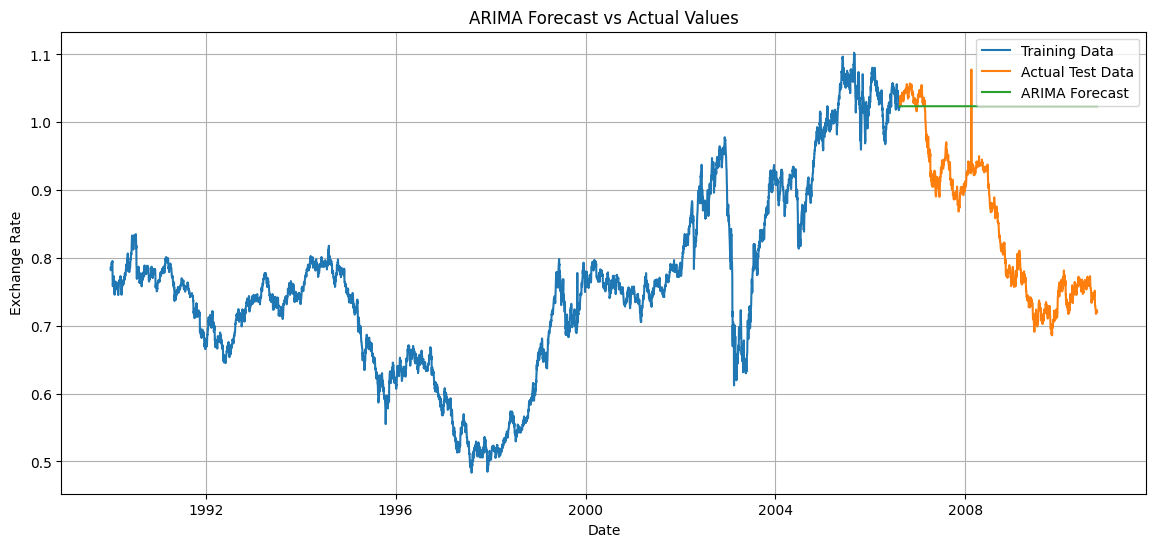

In [40]:
arima_forecast = arima_result.forecast(steps=len(test))

# Make forecast index same as test index
arima_forecast = pd.Series(arima_forecast.values, index=test.index)

plt.figure(figsize=(14, 6))
plt.plot(train.index, train, label='Training Data')
plt.plot(test.index, test, label='Actual Test Data')
plt.plot(arima_forecast.index, arima_forecast, label='ARIMA Forecast')
plt.title('ARIMA Forecast vs Actual Values')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.grid(True)
plt.show()

Explanation

Here, the ARIMA model forecasts exchange rate values for the testing period.
The graph compares the actual test values with the ARIMA predicted values.

# **Exponential Smoothing Model**

**Build Exponential Smoothing Model**

In [41]:
exp_model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal=None
)

exp_result = exp_model.fit()

exp_forecast = exp_result.forecast(steps=len(test))

exp_forecast = pd.Series(exp_forecast.values, index=test.index)

Explanation

Exponential Smoothing is another forecasting method.
It gives more importance to recent observations.

Here, additive trend is used and seasonality is not used because exchange rate data usually does not have clear fixed seasonal patterns.

# **Plot Exponential Smoothing Forecast**

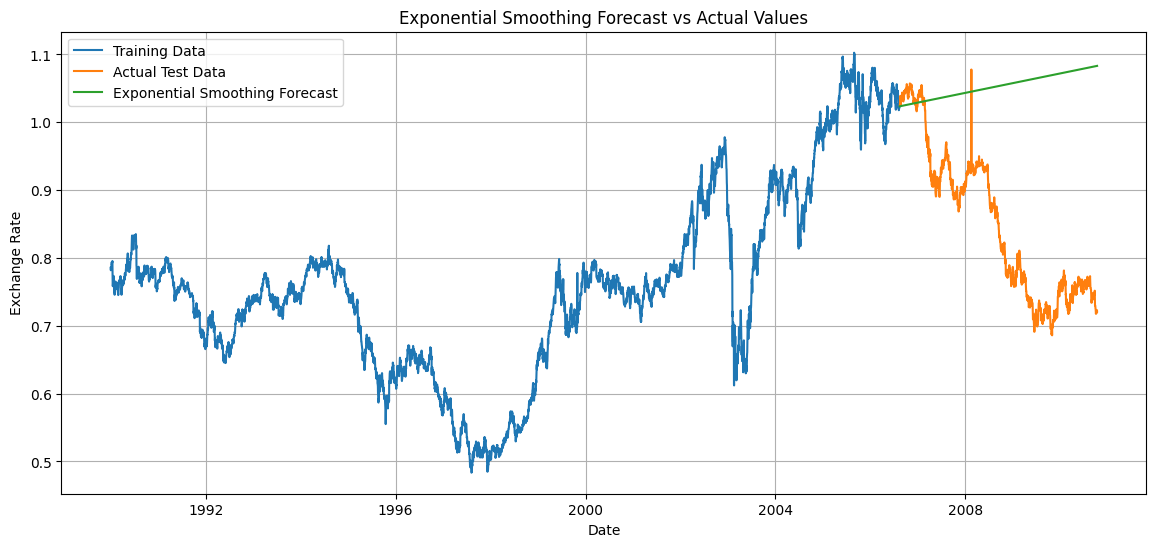

In [42]:
plt.figure(figsize=(14, 6))
plt.plot(train.index, train, label='Training Data')
plt.plot(test.index, test, label='Actual Test Data')
plt.plot(exp_forecast.index, exp_forecast, label='Exponential Smoothing Forecast')
plt.title('Exponential Smoothing Forecast vs Actual Values')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.grid(True)
plt.show()

Explanation

This graph compares the Exponential Smoothing forecast with the actual test values.

# **Model Evaluation**

**Create Evaluation Function**

In [43]:
def evaluate_model(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100

    return mae, rmse, mape

Explanation

This function calculates three error metrics:

MAE  = Mean Absolute Error
RMSE = Root Mean Squared Error
MAPE = Mean Absolute Percentage Error

Lower values of these metrics mean better model performance.

# **Evaluate Both Models**

In [44]:
arima_mae, arima_rmse, arima_mape = evaluate_model(test, arima_forecast)

exp_mae, exp_rmse, exp_mape = evaluate_model(test, exp_forecast)

print("ARIMA Model Performance")
print("MAE:", arima_mae)
print("RMSE:", arima_rmse)
print("MAPE:", arima_mape)

print("\nExponential Smoothing Model Performance")
print("MAE:", exp_mae)
print("RMSE:", exp_rmse)
print("MAPE:", exp_mape)

ARIMA Model Performance
MAE: 0.17770970449121345
RMSE: 0.2054366965966928
MAPE: 22.797966173811552

Exponential Smoothing Model Performance
MAE: 0.20659619114093827
RMSE: 0.23910443161792286
MAPE: 26.50866379878783


Explanation

This step calculates error values for both ARIMA and Exponential Smoothing models.
These values are used to compare the performance of both models.

# **Model Comparison Table**

In [45]:
comparison = pd.DataFrame({
    'Model': ['ARIMA', 'Exponential Smoothing'],
    'MAE': [arima_mae, exp_mae],
    'RMSE': [arima_rmse, exp_rmse],
    'MAPE': [arima_mape, exp_mape]
})

comparison

,Model,MAE,RMSE,MAPE
0,ARIMA,0.177710,0.205437,22.797966
1,Exponential Smoothing,0.206596,0.239104,26.508664


Explanation

This table shows the performance comparison of both models.
The model with lower MAE, RMSE, and MAPE is considered better.

From the comparison table, it is observed that the ARIMA model gives lower error values than the Exponential Smoothing model.

The ARIMA model has a MAE of 0.177710, RMSE of 0.205437, and MAPE of 22.797966%. On the other hand, the Exponential Smoothing model has a MAE of 0.206596, RMSE of 0.239104, and MAPE of 26.508664%.

Since ARIMA has lower MAE, RMSE, and MAPE values, it performs better for this exchange rate forecasting dataset.

# **Plot Both Model Forecasts Together**

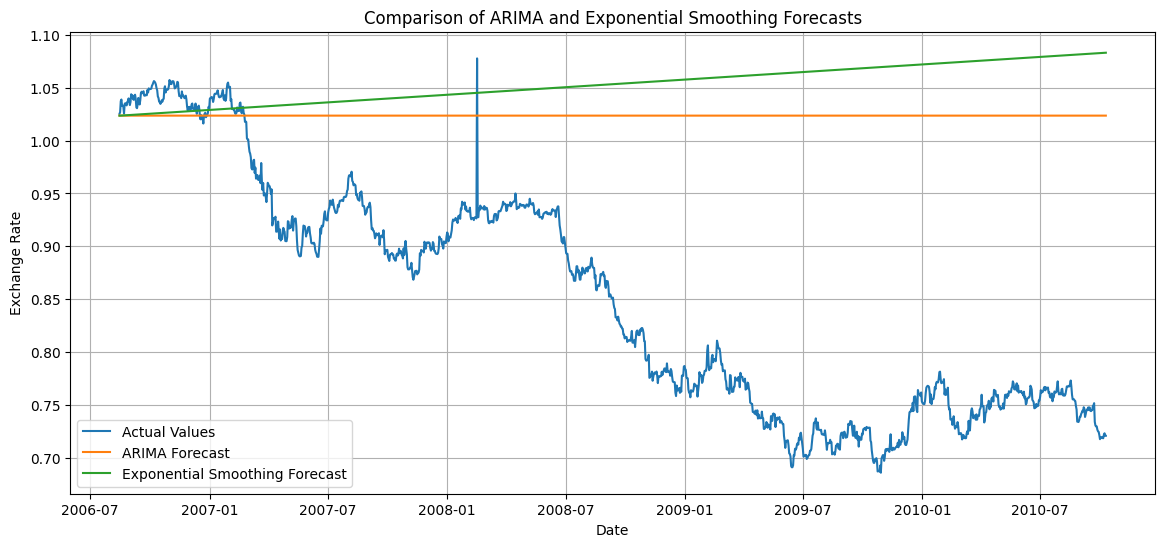

In [46]:
plt.figure(figsize=(14, 6))
plt.plot(test.index, test, label='Actual Values')
plt.plot(arima_forecast.index, arima_forecast, label='ARIMA Forecast')
plt.plot(exp_forecast.index, exp_forecast, label='Exponential Smoothing Forecast')
plt.title('Comparison of ARIMA and Exponential Smoothing Forecasts')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.grid(True)
plt.show()

Explanation

This plot compares both model forecasts with the actual values.
It helps us visually understand which model is closer to the actual exchange rate values.

# **Find the Best Model Automatically**

In [47]:
if arima_rmse < exp_rmse:
    best_model = "ARIMA"
else:
    best_model = "Exponential Smoothing"

print("Best model based on RMSE is:", best_model)

Best model based on RMSE is: ARIMA


Explanation

Here, the best model is selected based on RMSE value.
The model with lower RMSE is considered better.

# **Final Conclusion**

In this assignment, exchange rate forecasting was performed using ARIMA and Exponential Smoothing models.

First, the dataset was loaded and the date column was converted into datetime format. The date column was set as the index because this is a time series dataset. Basic exploration was done by checking dataset information, summary statistics, and missing values.

The exchange rate time series was plotted to understand its trend and fluctuations. The ADF test was used to check stationarity, and differencing was applied to make the series more stable. ACF and PACF plots were used to understand the parameters for the ARIMA model.

After that, an ARIMA model with order (1,1,1) was built and used for forecasting. The residuals of the ARIMA model were also analyzed. Then, an Exponential Smoothing model was built and used for forecasting.

Both models were evaluated using MAE, RMSE, and MAPE. The ARIMA model gave lower error values compared to the Exponential Smoothing model. Therefore, ARIMA performed better for this exchange rate forecasting dataset.

Overall, this assignment shows that time series forecasting techniques like ARIMA and Exponential Smoothing can be used to forecast future exchange rate values using historical data.